In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("C:/Users/prasa/OneDrive/Documents/Data Analyst projects/Combined Projects/amazon.csv")

In [3]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,13-04-2022,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,12-03-2023,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,28-09-2022,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,17-04-2022,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,13-03-2022,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [16]:
df.shape

(50000, 13)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          50000 non-null  int64         
 1   order_date        50000 non-null  datetime64[ns]
 2   product_id        50000 non-null  int64         
 3   product_category  50000 non-null  object        
 4   price             50000 non-null  float64       
 5   discount_percent  50000 non-null  int64         
 6   quantity_sold     50000 non-null  int64         
 7   customer_region   50000 non-null  object        
 8   payment_method    50000 non-null  object        
 9   rating            50000 non-null  float64       
 10  review_count      50000 non-null  int64         
 11  discounted_price  50000 non-null  float64       
 12  total_revenue     50000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(5), object(3)
memory usage: 5.0+ MB


In [12]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [13]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [14]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [10]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

In [11]:
df['revenue_per_product'] = df['discounted_price'] * df['quantity_sold']

In [12]:
total_revenue = df['total_revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 32866573.740000002


In [13]:
category_sales = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

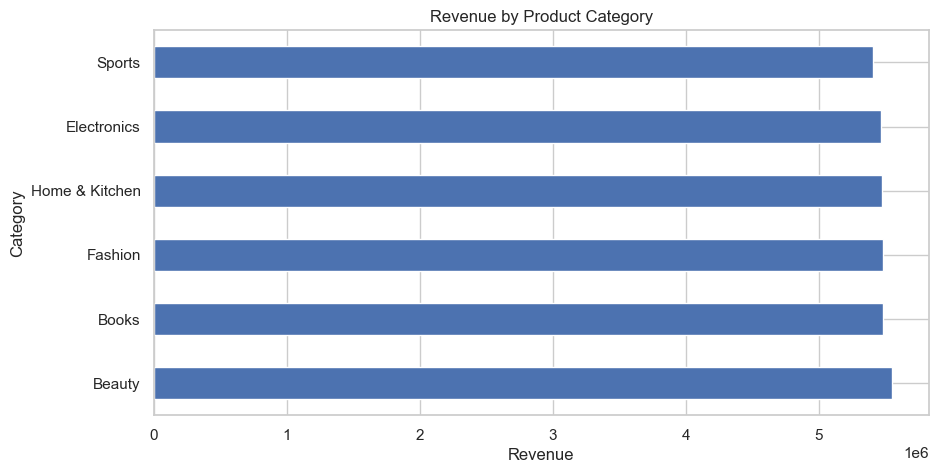

In [14]:
plt.figure(figsize=(10,5))
category_sales.plot(kind='barh')
plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

In [15]:
region_sales = df.groupby('customer_region')['total_revenue'].sum()

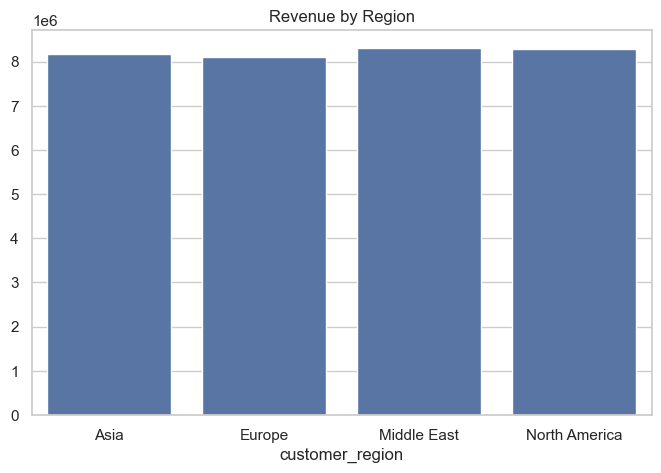

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Revenue by Region")
plt.show()

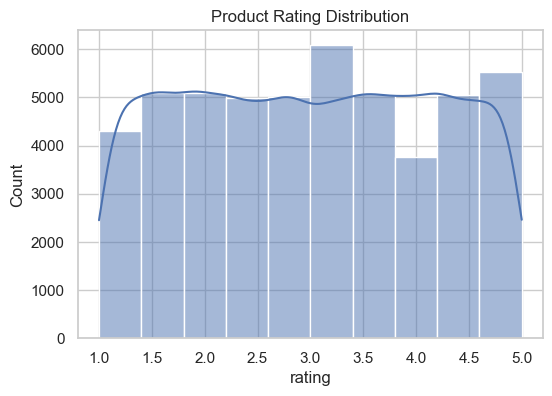

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Product Rating Distribution")
plt.show()

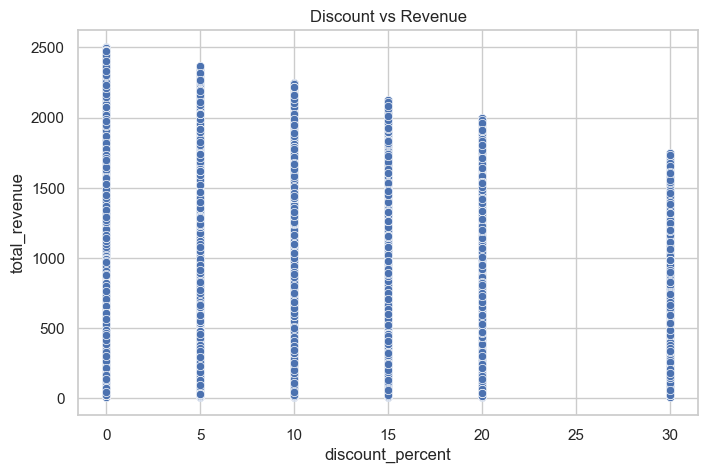

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discount_percent', y='total_revenue', data=df)
plt.title("Discount vs Revenue")
plt.show()

In [19]:
monthly_sales = df.groupby('month')['total_revenue'].sum()

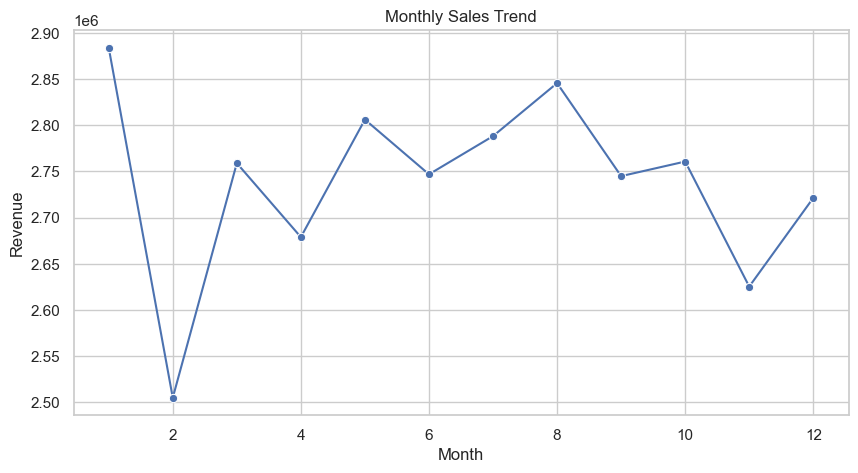

In [20]:
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [21]:
!pip install pymysql sqlalchemy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "root"
host = "localhost"
port = "3306"
database = "amazon_sales_analysis"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "amazon_sales_data" # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM amazon_sales_data LIMIT 5;", engine)

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,revenue_per_product
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,806.72
